In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import os
import pandas as pd

In [39]:
# Download absorption coefficients of Water

PATH_WATER = "Data_eau.csv"

water_df = pd.read_csv(PATH_WATER, header=None, names=["wavelength", "Water_abs"])
water_df["Water_abs_mm-1"] = (water_df["Water_abs"].values)/10

# target wavelength grid
wl_grid = np.arange(600, 1001, 2)   # 600, 602, 604, ..., 1000

# interpolate
water_interp = np.interp(wl_grid, water_df["wavelength"].values, water_df["Water_abs_mm-1"].values)

water_interp_df = pd.DataFrame({
    "wavelength": wl_grid,
    "Water_abs_mm-1": water_interp
})

wavelength_water = water_interp_df["wavelength"].values
mu_a_water = water_interp_df["Water_abs_mm-1"].values

print(water_interp_df)

     wavelength  Water_abs_mm-1
0           600        0.000190
1           602        0.000201
2           604        0.000212
3           606        0.000223
4           608        0.000234
..          ...             ...
196         992        0.035021
197         994        0.035351
198         996        0.035680
199         998        0.036010
200        1000        0.036339

[201 rows x 2 columns]


In [40]:
# Download extinction coefficients for HbO2 and Hb

df = pd.read_csv("hemoglobin_extinction_partial.csv")

x = 150  # g/L
df["mu_a_HbO2_mm-1"] = (2.303 * df["HbO2_cm-1_M"] * x / 64500)/10
df["mu_a_Hb_mm-1"]   = (2.303 * df["Hb_cm-1_M"]  * x / 64500)/10
df = df[df["lambda_nm"].between(600, 1000)]

wavelength = df["lambda_nm"].values
mu_a_HbO2 = df["mu_a_HbO2_mm-1"].values
mu_a_Hb = df["mu_a_Hb_mm-1"].values

print(df)

     lambda_nm  HbO2_cm-1_M  Hb_cm-1_M  mu_a_HbO2_mm-1  mu_a_Hb_mm-1
175      600.0       3200.0  14677.200        1.713860      7.860835
176      602.0       2664.0  13622.400        1.426789      7.295904
177      604.0       2128.0  12567.600        1.139717      6.730973
178      606.0       1789.2  11513.200        0.958262      6.166256
179      608.0       1647.6  10477.600        0.882424      5.611608
..         ...          ...        ...             ...           ...
371      992.0       1068.8    267.932        0.572429      0.143499
372      994.0       1057.6    252.648        0.566431      0.135314
373      996.0       1046.4    237.360        0.560432      0.127126
374      998.0       1035.2    222.072        0.554434      0.118938
375     1000.0       1024.0    206.784        0.548435      0.110750

[201 rows x 5 columns]


In [ ]:
# Create original mesh

# --- 1. Define mesh grid ---
x_max = 10
x_step = 0.1
x = np.arange(0, x_max + x_step, x_step)

layer_thickness = [0.02, 0.25, 0.10, 0.08, 0.20, 0.30]
z_max = sum(layer_thickness)
z_step = 0.001
z = np.arange(0, z_max, z_step)

X, Z = np.meshgrid(x, z)

# --- 2. Initialize property arrays ---
n = np.zeros_like(X)
mu_s = np.zeros_like(X)

# 3D absorption array
mu_a = np.zeros((len(wavelength), *X.shape))

# --- 3. Assign refractive index and scattering ---
layer_edges = np.cumsum(layer_thickness)

mask = Z < layer_edges[1]
n[mask] = 1.42
mu_s[mask] = 20.1

mask = Z >= layer_edges[1]
n[mask] = 1.39
mu_s[mask] = 20.1


# --- Layer masks ---
stratum = Z < layer_edges[0]
epiderme = (Z >= layer_edges[0]) & (Z < layer_edges[1])
papille_dermique = (Z >= layer_edges[1]) & (Z < layer_edges[2])
derme_supérieur = (Z >= layer_edges[2]) & (Z < layer_edges[3])
derme_réticulaire = (Z >= layer_edges[3]) & (Z < layer_edges[4])
derme_profond = (Z >= layer_edges[4]) & (Z <= layer_edges[5])


# --- Precompute wavelength dependent spectra ---
mu_a_mel = 6.6e10 * (wavelength ** -3.33)
mu_a_baseline = 7.84e7 * (wavelength ** -3.255)

V_mel = 0.1


for i, wn in enumerate(wavelength):

    mu_mel = mu_a_mel[i]
    mu_baseline = mu_a_baseline[i]
    mu_water = mu_a_water[i]

    # --- Stratum corneum ---
    V_water_stratum = 0.05
    mu_stratum = (
        V_mel * mu_mel +
        V_water_stratum * mu_water +
        (1 - (V_mel + V_water_stratum)) * mu_baseline
    )

    mu_a[i][stratum] = mu_stratum


    # --- Epidermis ---
    V_water_epiderme = 0.2
    mu_epiderme = (
        V_mel * mu_mel +
        V_water_epiderme * mu_water +
        (1 - (V_mel + V_water_epiderme)) * mu_baseline
    )

    mu_a[i][epiderme] = mu_epiderme


    # --- Hemoglobin absorption ---
    mu_Hb = mu_a_Hb[i]
    mu_HbO2 = mu_a_HbO2[i]

    SaO2 = 0.98
    SvO2 = SaO2 - 0.1

    mu_A = SaO2 * mu_HbO2 + (1 - SaO2) * mu_Hb
    mu_V = SvO2 * mu_HbO2 + (1 - SvO2) * mu_Hb


    # --- Papillary dermis ---
    Vb = 0.04
    Vw = 0.5

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][papille_dermique] = mu_val


    # --- Upper dermis ---
    Vb = 0.3
    Vw = 0.6

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_supérieur] = mu_val


    # --- Reticular dermis ---
    Vb = 0.04
    Vw = 0.7

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_réticulaire] = mu_val


    # --- Deep dermis ---
    Vb = 0.1
    Vw = 0.7

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_profond] = mu_val

print(mu_a.shape)

(201, 950, 101)


In [105]:
import numpy as np

def simulate_light_propagation(mu_abs, mu_s, n):
    g = 0.9
    Wc = 0.01
    m = 10
    Nz, Nx = mu_abs.shape
    N_photons = 5000

    rng = np.random.default_rng()

    # initialize absorption map
    A = np.zeros_like(mu_abs)

    # compute max coordinates
    x_max = Nx * x_step
    z_max = Nz * z_step

    for p in range(N_photons):
        W = 1.0
        mu_x = 0
        mu_z = 1
        x = x_max / 2
        z = 0

        while True:
            # convert to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop photon if outside medium
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient at current voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                print("Shit")
                break  # stop photon if no scattering/absorption

            # mean free path
            s = -np.log(rng.uniform()) / mu_t

            # --- Fresnel reflection/transmission ---
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step)
            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]
                if n1 != n2:  # interface detected
                    theta_i = np.arccos(abs(mu_z))  # angle with normal
                    sin_theta_t = n1 / n2 * np.sin(theta_i)
                    if sin_theta_t > 1:  # total internal reflection
                        mu_z = -mu_z
                    else:
                        theta_t = np.arcsin(sin_theta_t)
                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)
                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) / 
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) / 
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)
                        if rng.uniform() < R:
                            mu_z = -mu_z  # reflect
                        else:
                            mu_z = np.sign(mu_z) * cos_theta_t  # transmit
                            # adjust horizontal component to conserve direction magnitude
                            if np.sin(theta_i) < 1e-12:  # photon moving almost perfectly vertical
                                # horizontal component stays the same
                                mu_x = mu_x
                            else:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # convert new positions to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # recalc total interaction coefficient at new voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]

            # absorption
            deltaW = (mu_abs[iz, ix]/mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1/m:
                    W *= m
                else:
                    break

            # Diffusion (2D Henyey-Greenstein)
            e2 = rng.uniform()
            e3 = rng.uniform()
            phi = 2 * np.pi * e2
            cos_theta = (1/(2*g))*(1 + g**2 - ((1-g**2)/(1-g + 2*g*e3))**2)
            sin_theta = np.sqrt(1 - cos_theta**2)
            mu_x_new = sin_theta * np.cos(phi)
            mu_z_new = np.sign(mu_z) * cos_theta
            mu_x, mu_z = mu_x_new, mu_z_new

    A /= N_photons
    return A

600.0
3.761223544349355
602.0
3.71978904027385
604.0
3.678946172148853
606.0
3.6386845748812626
608.0
3.5989940983381343
610.0
3.5598648022011217
612.0
3.521286689007962
614.0
3.4832504060169502
616.0
3.445746691976586
618.0
3.4087663970992077
620.0
3.3723005576943663
622.0
3.3363403917997974
624.0
3.300877294928571
626.0
3.2659028359289906
628.0
3.2314087529539037
630.0
3.197386949536193
632.0
3.1638294907673243
634.0
3.130728599575924
636.0
3.098076653103484
638.0
3.065866179174331
640.0
3.034089852857151
642.0
3.0027404931154047
644.0
2.9718110595440668
646.0
2.941294649190211
648.0
2.9111844934550306
650.0
2.88147395507497
652.0
2.852156525179703
654.0
2.8232258204247858
656.0
2.7946755801968544
658.0
2.766499828966829
660.0
2.7386924815707996
662.0
2.711247526345839
664.0
2.684159167035534
666.0
2.657421717159276
668.0
2.6310295976118896
670.0
2.604977334322726
672.0
2.579259555972586
674.0
2.553870991766875
676.0
2.5288064692634356
678.0
2.5040609122535713
680.0
2.479629338694797

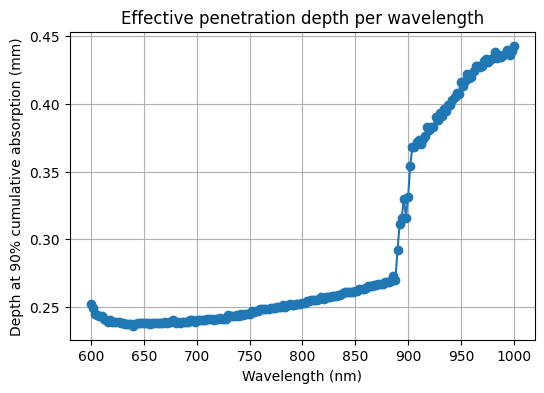

In [6]:
import numpy as np
import matplotlib.pyplot as plt

X_PERCENT = 0.9  # 90% of absorbed energy
max_depths = []

for i, wl in enumerate(wavelength):
    print(wl)
    mu_a_current = mu_a[i]  # absorption map (Nz, Nx)
    print(mu_a_current.max())
    A = simulate_light_propagation(mu_a_current, mu_s, n)  # returns (Nz, Nx)

    # sum absorption along x to get total absorbed energy per z
    absorption_per_z = A.sum(axis=1)  # shape (Nz,)

    # cumulative absorption from surface to depth
    cumulative = np.cumsum(absorption_per_z)

    # normalize to fraction of total absorbed energy
    cumulative_frac = cumulative / cumulative[-1]

    # find the first depth where cumulative fraction >= X_PERCENT
    iz_90 = np.searchsorted(cumulative_frac, X_PERCENT)

    depth_90 = iz_90 * z_step  # convert index to physical depth
    max_depths.append(depth_90)

# plot
plt.figure(figsize=(6,4))
plt.plot(wavelength, max_depths, '-o')
plt.xlabel("Wavelength (nm)")
plt.ylabel(f"Depth at {int(X_PERCENT*100)}% cumulative absorption (mm)")
plt.title("Effective penetration depth per wavelength")
plt.grid(True)
plt.show()

# EXPLORATION

In [ ]:
import numpy as np

def simulate_light_propagation(mu_abs, mu_s, n, theta0_deg, N_photons=5000):
    g = 0.9
    Wc = 0.01
    m = 10
    Nz, Nx = mu_abs.shape

    rng = np.random.default_rng()

    # initialize absorption map
    A = np.zeros_like(mu_abs)

    # compute max coordinates
    x_max = Nx * x_step
    z_max = Nz * z_step

    # initial angle, measured from +z axis
    # theta0_deg = 0   -> straight down
    # theta0_deg > 0   -> tilted toward +x
    # theta0_deg < 0   -> tilted toward -x
    theta0 = np.deg2rad(theta0_deg)

    for p in range(N_photons):
        W = 1.0

        # only change from your original launch:
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max / 2
        z = 0

        while True:
            # convert to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop photon if outside medium
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient at current voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # mean free path
            s = -np.log(rng.uniform()) / mu_t

            # --- Fresnel reflection/transmission ---
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2:  # interface detected
                    theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))  # angle with normal
                    sin_theta_t = (n1 / n2) * np.sin(theta_i)

                    if sin_theta_t > 1:
                        # total internal reflection
                        mu_z = -mu_z
                    else:
                        theta_t = np.arcsin(sin_theta_t)
                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)

                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)

                        if rng.uniform() < R:
                            mu_z = -mu_z  # reflect
                        else:
                            mu_z = np.sign(mu_z) * cos_theta_t  # transmit

                            # adjust horizontal component
                            if np.sin(theta_i) < 1e-12:
                                mu_x = mu_x
                            else:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # convert new positions to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # recalc total interaction coefficient at new voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # absorption
            deltaW = (mu_abs[iz, ix] / mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # Diffusion / scattering in 2D relative to current direction
            e3 = rng.uniform()

            cos_delta = (1/(2*g)) * (
                1 + g**2 - ((1 - g**2)/(1 - g + 2*g*e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)

            # random left/right scattering in 2D
            if rng.uniform() < 0.5:
                delta = -delta

            # rotate direction vector
            mu_x_new = mu_x*np.cos(delta) + mu_z*np.sin(delta)
            mu_z_new = -mu_x*np.sin(delta) + mu_z*np.cos(delta)

            # normalize (important for numerical stability)
            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            mu_x = mu_x_new / norm
            mu_z = mu_z_new / norm

            print(mu_z)
            print(mu_x)
            print(R)

    A /= N_photons
    return A

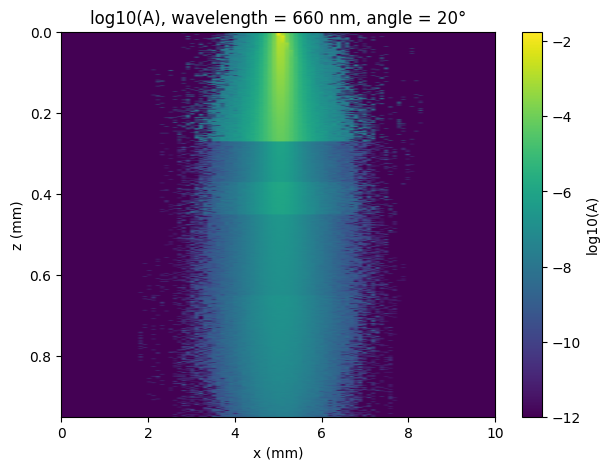

In [87]:
wl_test = 660
i_test = np.where(wavelength == wl_test)[0][0]

A_test = simulate_light_propagation(mu_a[i_test], mu_s, n, theta0_deg=80, N_photons=500000)

plt.figure(figsize=(7,5))
plt.imshow(np.log10(A_test + 1e-12),
           extent=[0, x_max, z_max, 0],
           aspect='auto',
           cmap='viridis')
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title(f"log10(A), wavelength = {wl_test} nm, angle = 20°")
plt.colorbar(label="log10(A)")
plt.show()

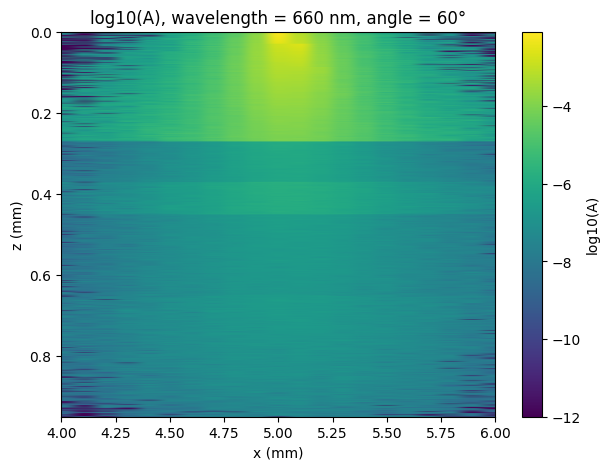

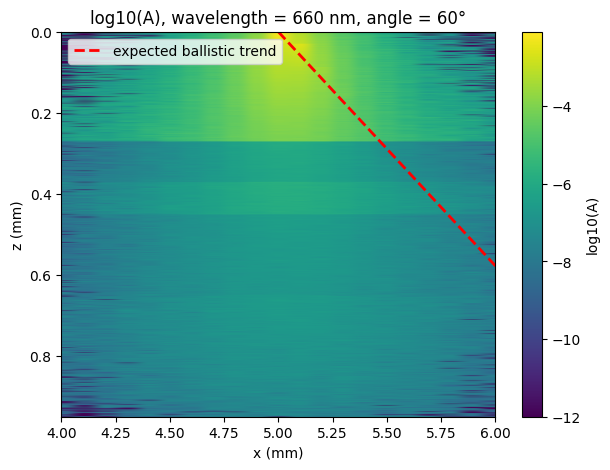

In [82]:
wl_test = 660
theta_test = 60
N_test = 50000

i_test = np.where(wavelength == wl_test)[0][0]
A_test = simulate_light_propagation(mu_a[i_test], mu_s, n, theta0_deg=theta_test, N_photons=N_test)

plt.figure(figsize=(7,5))
plt.imshow(np.log10(A_test + 1e-12),
           extent=[0, x_max, z_max, 0],
           aspect='auto',
           cmap='viridis')

x_center = x_max / 2
plt.xlim(x_center - 1.0, x_center + 1.0)   # zoom near beam
plt.ylim(z_max, 0)

plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title(f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°")
plt.colorbar(label="log10(A)")
plt.show()

plt.figure(figsize=(7,5))
plt.imshow(np.log10(A_test + 1e-12),
           extent=[0, x_max, z_max, 0],
           aspect='auto',
           cmap='viridis')

theta_rad = np.deg2rad(theta_test)
z_line = np.linspace(0, z_max, 200)
x_line = x_max/2 + z_line * np.tan(theta_rad)

plt.plot(x_line, z_line, 'r--', linewidth=2, label='expected ballistic trend')

plt.xlim(x_max/2 - 1.0, x_max/2 + 1.0)
plt.ylim(z_max, 0)

plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title(f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°")
plt.colorbar(label="log10(A)")
plt.legend()
plt.show()

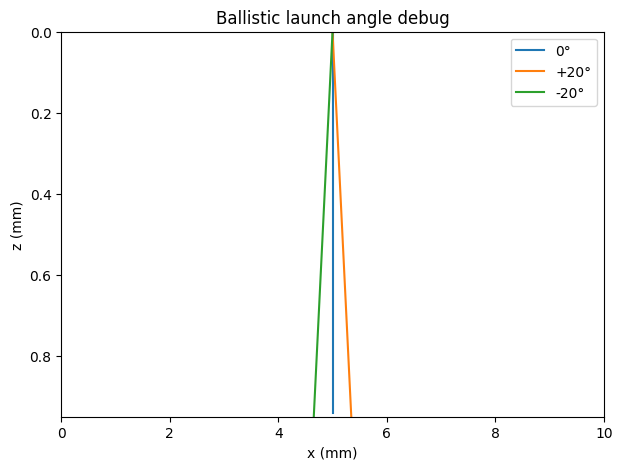

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def trace_ballistic_photon(theta0_deg=20, n_steps=200):
    """
    Debug only:
    propagate one photon with chosen launch angle
    with NO scattering and NO absorption,
    just to verify the initial direction is working.
    """
    theta0 = np.deg2rad(theta0_deg)

    x = x_max / 2
    z = 0.0

    mu_x = np.sin(theta0)
    mu_z = np.cos(theta0)

    xs = [x]
    zs = [z]

    s = 0.01  # fixed small step in mm for visualization

    for _ in range(n_steps):
        x += mu_x * s
        z += mu_z * s

        if x < 0 or x > x_max or z < 0 or z > z_max:
            break

        xs.append(x)
        zs.append(z)

    return np.array(xs), np.array(zs)


xs0, zs0 = trace_ballistic_photon(theta0_deg=0)
xs20, zs20 = trace_ballistic_photon(theta0_deg=20)
xsm20, zsm20 = trace_ballistic_photon(theta0_deg=-20)

plt.figure(figsize=(7,5))
plt.plot(xs0, zs0, label="0°")
plt.plot(xs20, zs20, label="+20°")
plt.plot(xsm20, zsm20, label="-20°")
plt.gca().invert_yaxis()
plt.xlim(0, x_max)
plt.ylim(z_max, 0)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title("Ballistic launch angle debug")
plt.legend()
plt.show()

In [85]:
import numpy as np

def simulate_first_step_map(mu_abs, mu_s, n, theta0_deg=0.0, N_photons=50000):
    """
    Debug map:
    launch photons at theta0_deg,
    propagate only ONE interaction step,
    deposit absorption once,
    then stop.

    This isolates the incident-angle effect before repeated scattering dominates.
    """
    Nz, Nx = mu_abs.shape
    A1 = np.zeros_like(mu_abs, dtype=float)

    rng = np.random.default_rng()
    theta0 = np.deg2rad(theta0_deg)

    x0 = x_max / 2
    z0 = 0.0

    for _ in range(N_photons):
        x = x0
        z = z0
        W = 1.0

        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        ix = int(x / x_step)
        iz = int(z / z_step)

        if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
            continue

        mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
        if mu_t <= 0:
            continue

        s = -np.log(rng.uniform()) / mu_t

        x = x + mu_x * s
        z = z + mu_z * s

        ix = int(x / x_step)
        iz = int(z / z_step)

        if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
            continue

        mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
        if mu_t <= 0:
            continue

        deltaW = (mu_abs[iz, ix] / mu_t) * W
        A1[iz, ix] += deltaW

    A1 /= N_photons
    return A1

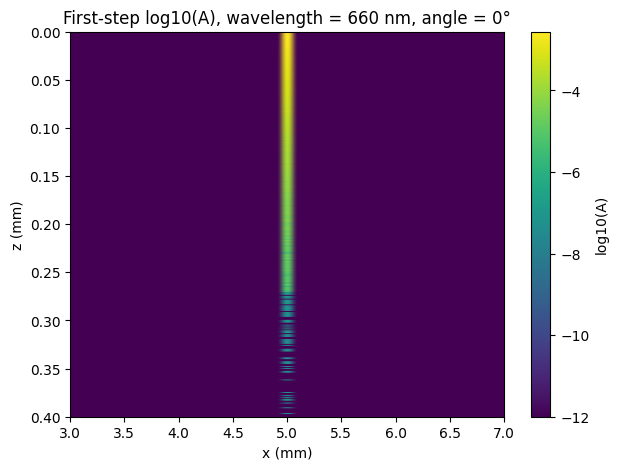

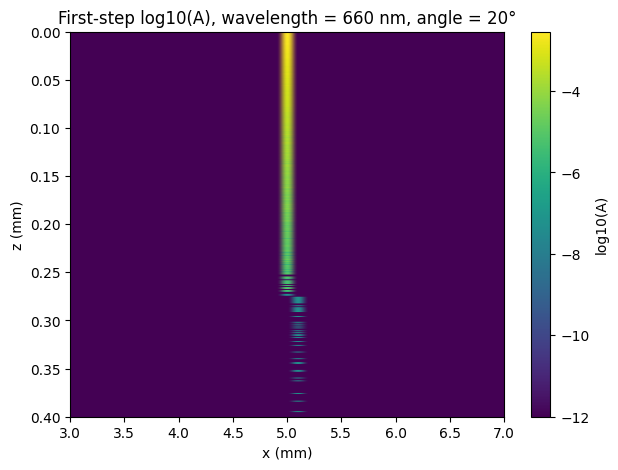

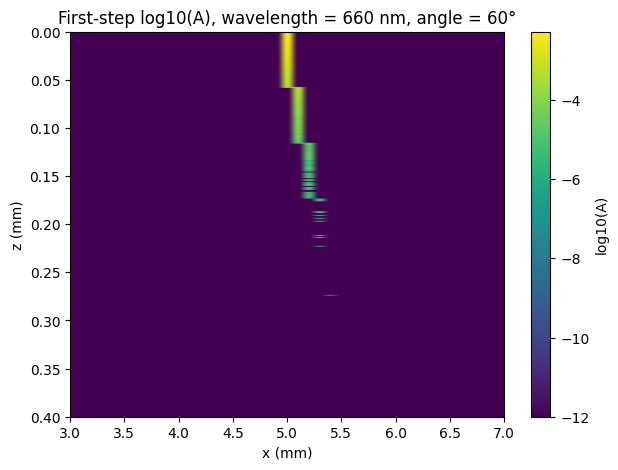

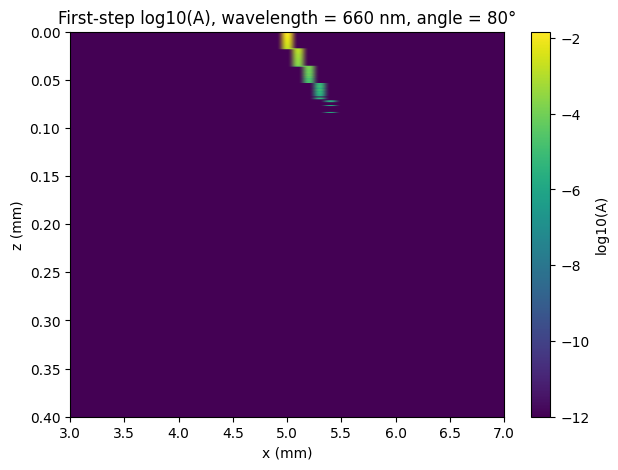

In [86]:
wl_test = 660
i_test = np.where(wavelength == wl_test)[0][0]

for ang in [0, 20, 60, 80]:
    A1 = simulate_first_step_map(mu_a[i_test], mu_s, n, theta0_deg=ang, N_photons=50000)

    plt.figure(figsize=(7,5))
    plt.imshow(np.log10(A1 + 1e-12),
               extent=[0, x_max, z_max, 0],
               aspect='auto',
               cmap='viridis')
    plt.xlim(x_max/2 - 2, x_max/2 + 2)
    plt.ylim(0.4, 0)
    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(f"First-step log10(A), wavelength = {wl_test} nm, angle = {ang}°")
    plt.colorbar(label="log10(A)")
    plt.show()

In [89]:
import numpy as np

def trace_single_photon_debug(mu_abs, mu_s, n, theta0_deg=80, max_steps=50, seed=123):
    g = 0.9
    Wc = 0.01
    m = 10
    Nz, Nx = mu_abs.shape

    rng = np.random.default_rng(seed)

    x_max_local = Nx * x_step
    z_max_local = Nz * z_step

    W = 1.0
    theta0 = np.deg2rad(theta0_deg)

    mu_x = np.sin(theta0)
    mu_z = np.cos(theta0)

    x = x_max_local / 2
    z = 0.0

    print("="*80)
    print(f"Single photon debug")
    print(f"theta0_deg = {theta0_deg}")
    print(f"initial mu_x = {mu_x:.6f}, mu_z = {mu_z:.6f}")
    print(f"initial x = {x:.6f}, z = {z:.6f}")
    print("="*80)

    for step_id in range(max_steps):
        ix = int(x / x_step)
        iz = int(z / z_step)

        if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
            print(f"[STOP] Photon left medium at step {step_id}")
            break

        mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
        if mu_t <= 0:
            print(f"[STOP] mu_t <= 0 at step {step_id}")
            break

        s = -np.log(rng.uniform()) / mu_t

        x_old, z_old = x, z
        mu_x_old, mu_z_old = mu_x, mu_z

        next_x = x + mu_x * s
        next_z = z + mu_z * s

        next_ix = int(next_x / x_step) if 0 <= next_x < x_max_local else -1
        next_iz = int(next_z / z_step) if 0 <= next_z < Nz * z_step else -1

        print(f"\nStep {step_id}")
        print(f"  current voxel: ix={ix}, iz={iz}")
        print(f"  x={x:.6f}, z={z:.6f}")
        print(f"  mu_x={mu_x:.6f}, mu_z={mu_z:.6f}")
        print(f"  mu_t={mu_t:.6f}, s={s:.6f}")
        print(f"  predicted next_x={next_x:.6f}, next_z={next_z:.6f}")
        print(f"  predicted next_ix={next_ix}, next_iz={next_iz}")

        # Fresnel interface check in z only, same logic as your current code
        if 0 <= next_iz < Nz:
            n1 = n[iz, ix]
            n2 = n[next_iz, ix]

            if n1 != n2:
                theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))
                sin_theta_t = (n1 / n2) * np.sin(theta_i)

                print("  [INTERFACE DETECTED]")
                print(f"    n1={n1:.6f}, n2={n2:.6f}")
                print(f"    theta_i_deg={np.rad2deg(theta_i):.6f}")
                print(f"    sin_theta_t={sin_theta_t:.6f}")

                if sin_theta_t > 1:
                    print("    -> TOTAL INTERNAL REFLECTION")
                    mu_z = -mu_z
                else:
                    theta_t = np.arcsin(sin_theta_t)
                    cos_theta_i = np.cos(theta_i)
                    cos_theta_t = np.cos(theta_t)

                    Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                          (n1 * cos_theta_i + n2 * cos_theta_t))**2
                    Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                          (n1 * cos_theta_t + n2 * cos_theta_i))**2
                    R = 0.5 * (Rs + Rp)

                    print(f"    theta_t_deg={np.rad2deg(theta_t):.6f}")
                    print(f"    Rs={Rs:.6f}, Rp={Rp:.6f}, R={R:.6f}")

                    u_reflect = rng.uniform()
                    print(f"    random draw for reflection = {u_reflect:.6f}")

                    if u_reflect < R:
                        print("    -> REFLECTION")
                        mu_z = -mu_z
                    else:
                        print("    -> TRANSMISSION")
                        old_mu_x = mu_x
                        old_mu_z = mu_z
                        mu_z = np.sign(mu_z) * cos_theta_t

                        if np.sin(theta_i) >= 1e-12:
                            mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                        norm = np.sqrt(mu_x**2 + mu_z**2)
                        mu_x /= norm
                        mu_z /= norm

                        print(f"    mu before transmit fix: ({old_mu_x:.6f}, {old_mu_z:.6f})")
                        print(f"    mu after transmit fix:  ({mu_x:.6f}, {mu_z:.6f})")

        # propagate
        x += mu_x * s
        z += mu_z * s

        ix = int(x / x_step)
        iz = int(z / z_step)

        if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
            print(f"  [STOP] Photon left medium after propagation at step {step_id}")
            break

        mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
        if mu_t <= 0:
            print(f"  [STOP] mu_t <= 0 after propagation at step {step_id}")
            break

        deltaW = (mu_abs[iz, ix] / mu_t) * W
        W -= deltaW

        print(f"  propagated to x={x:.6f}, z={z:.6f}")
        print(f"  new voxel ix={ix}, iz={iz}")
        print(f"  deltaW={deltaW:.6e}, W={W:.6e}")

        if W < Wc:
            u_rr = rng.uniform()
            print(f"  Russian roulette: u={u_rr:.6f}")
            if u_rr <= 1 / m:
                W *= m
                print(f"  survived roulette, new W={W:.6e}")
            else:
                print("  [STOP] Photon killed by Russian roulette")
                break

        # scattering
        e3 = rng.uniform()
        cos_delta = (1/(2*g)) * (
            1 + g**2 - ((1 - g**2)/(1 - g + 2*g*e3))**2
        )
        cos_delta = np.clip(cos_delta, -1.0, 1.0)
        delta = np.arccos(cos_delta)

        if rng.uniform() < 0.5:
            delta = -delta

        mu_x_new = mu_x*np.cos(delta) + mu_z*np.sin(delta)
        mu_z_new = -mu_x*np.sin(delta) + mu_z*np.cos(delta)

        norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
        mu_x = mu_x_new / norm
        mu_z = mu_z_new / norm

        print(f"  scatter delta_deg={np.rad2deg(delta):.6f}")
        print(f"  new direction mu_x={mu_x:.6f}, mu_z={mu_z:.6f}")

    print("="*80)
    print("End of single photon debug")
    print("="*80)

In [90]:
wl_test = 660
i_test = np.where(wavelength == wl_test)[0][0]

trace_single_photon_debug(mu_a[i_test], mu_s, n, theta0_deg=80, max_steps=20, seed=1)

Single photon debug
theta0_deg = 80
initial mu_x = 0.984808, mu_z = 0.173648
initial x = 5.050000, z = 0.000000

Step 0
  current voxel: ix=50, iz=0
  x=5.050000, z=0.000000
  mu_x=0.984808, mu_z=0.173648
  mu_t=22.838692, s=0.029327
  predicted next_x=5.078881, next_z=0.005092
  predicted next_ix=50, next_iz=5
  propagated to x=5.078881, z=0.005092
  new voxel ix=50, iz=5
  deltaW=1.199146e-01, W=8.800854e-01
  scatter delta_deg=-1.918566
  new direction mu_x=0.978442, mu_z=0.206521

Step 1
  current voxel: ix=50, iz=5
  x=5.078881, z=0.005092
  mu_x=0.978442, mu_z=0.206521
  mu_t=22.838692, s=0.002308
  predicted next_x=5.081139, next_z=0.005569
  predicted next_ix=50, next_iz=5
  propagated to x=5.081139, z=0.005569
  new voxel ix=50, iz=5
  deltaW=1.055351e-01, W=7.745503e-01
  scatter delta_deg=-16.322560
  new direction mu_x=0.880964, mu_z=0.473183

Step 2
  current voxel: ix=50, iz=5
  x=5.081139, z=0.005569
  mu_x=0.880964, mu_z=0.473183
  mu_t=22.838692, s=0.008280
  predicted

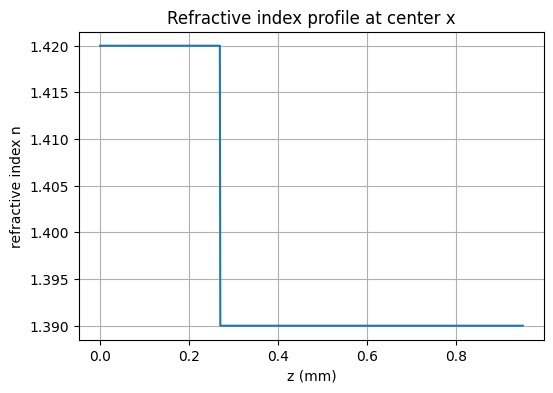

In [91]:
ix_mid = n.shape[1] // 2

plt.figure(figsize=(6,4))
plt.plot(np.arange(n.shape[0]) * z_step, n[:, ix_mid])
plt.xlabel("z (mm)")
plt.ylabel("refractive index n")
plt.title("Refractive index profile at center x")
plt.grid(True)
plt.show()

In [92]:
print("x_step =", x_step)
print("z_step =", z_step)
print("x_step / z_step =", x_step / z_step)

x_step = 0.1
z_step = 0.001
x_step / z_step = 100.0


In [93]:
import numpy as np

def refine_x_grid(field_2d, refine_factor=10):
    """
    Refine a 2D field along x by repeating each column.
    This keeps the original physics but gives a finer x discretization.

    Parameters
    ----------
    field_2d : 2D numpy array, shape (Nz, Nx)
    refine_factor : int
        Number of times each x-column is repeated.

    Returns
    -------
    refined_field : 2D numpy array, shape (Nz, Nx * refine_factor)
    """
    return np.repeat(field_2d, refine_factor, axis=1)

In [94]:
import numpy as np

def simulate_light_propagation(mu_abs, mu_s, n, theta0_deg, N_photons=5000,
                               debug=False, max_debug_prints=20):
    g = 0.9
    Wc = 0.01
    m = 10
    Nz, Nx = mu_abs.shape

    rng = np.random.default_rng()

    # initialize absorption map
    A = np.zeros_like(mu_abs, dtype=float)

    # compute max coordinates
    x_max_local = Nx * x_step
    z_max_local = Nz * z_step

    # initial angle, measured from +z axis
    # theta0_deg = 0   -> straight down
    # theta0_deg > 0   -> tilted toward +x
    # theta0_deg < 0   -> tilted toward -x
    theta0 = np.deg2rad(theta0_deg)

    debug_count = 0

    for p in range(N_photons):
        W = 1.0

        # initial launch direction
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2
        z = 0.0

        while True:
            # convert to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop photon if outside medium
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient at current voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # mean free path
            s = -np.log(rng.uniform()) / mu_t

            # initialize R in case no interface is crossed
            R = np.nan

            # --- Fresnel reflection/transmission ---
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2:  # interface detected
                    theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))  # angle with normal
                    sin_theta_t = (n1 / n2) * np.sin(theta_i)

                    if sin_theta_t > 1:
                        # total internal reflection
                        mu_z = -mu_z
                        R = 1.0
                    else:
                        theta_t = np.arcsin(sin_theta_t)
                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)

                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)

                        if rng.uniform() < R:
                            mu_z = -mu_z  # reflect
                        else:
                            mu_z = np.sign(mu_z) * cos_theta_t  # transmit

                            # adjust horizontal component
                            if np.sin(theta_i) >= 1e-12:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                            # normalize after transmission
                            norm = np.sqrt(mu_x**2 + mu_z**2)
                            if norm > 0:
                                mu_x /= norm
                                mu_z /= norm

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # convert new positions to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # recalc total interaction coefficient at new voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # absorption
            deltaW = (mu_abs[iz, ix] / mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # optional debug print
            if debug and debug_count < max_debug_prints:
                print(f"photon={p}, ix={ix}, iz={iz}, mu_x={mu_x:.6f}, mu_z={mu_z:.6f}, R={R}")
                debug_count += 1

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # Diffusion / scattering in 2D relative to current direction
            e3 = rng.uniform()

            cos_delta = (1/(2*g)) * (
                1 + g**2 - ((1 - g**2)/(1 - g + 2*g*e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)

            # random left/right scattering in 2D
            if rng.uniform() < 0.5:
                delta = -delta

            # rotate direction vector
            mu_x_new = mu_x*np.cos(delta) + mu_z*np.sin(delta)
            mu_z_new = -mu_x*np.sin(delta) + mu_z*np.cos(delta)

            # normalize
            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            if norm > 0:
                mu_x = mu_x_new / norm
                mu_z = mu_z_new / norm
            else:
                break

    A /= N_photons
    return A

In [95]:
# Choose how much to refine x
refine_factor = 10

# Refine the optical-property maps along x
mu_a_refined = refine_x_grid(mu_a[i_test], refine_factor=refine_factor)
mu_s_refined = refine_x_grid(mu_s, refine_factor=refine_factor)
n_refined    = refine_x_grid(n, refine_factor=refine_factor)

# Update x_step for the refined grid
x_step_old = x_step
x_step = x_step_old / refine_factor

print("Old x_step =", x_step_old)
print("New x_step =", x_step)
print("z_step     =", z_step)
print("x_step / z_step =", x_step / z_step)

Old x_step = 0.1
New x_step = 0.01
z_step     = 0.001
x_step / z_step = 10.0


In [99]:
wl_test = 660
theta_test = 80
N_test = 50000

i_test = np.where(wavelength == wl_test)[0][0]

A_test = simulate_light_propagation(
    mu_a_refined,
    mu_s_refined,
    n_refined,
    theta0_deg=theta_test,
    N_photons=N_test,
    debug=False
)

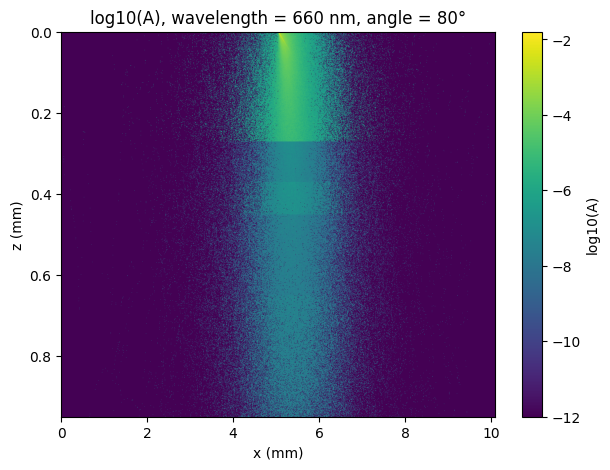

In [100]:
plt.figure(figsize=(7,5))
plt.imshow(np.log10(A_test + 1e-12),
           extent=[0, mu_a_refined.shape[1] * x_step, mu_a_refined.shape[0] * z_step, 0],
           aspect='auto',
           cmap='viridis')
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title(f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°")
plt.colorbar(label="log10(A)")
plt.show()

In [101]:
A_debug = simulate_light_propagation(
    mu_a_refined,
    mu_s_refined,
    n_refined,
    theta0_deg=80,
    N_photons=5,
    debug=True,
    max_debug_prints=50
)

photon=0, ix=506, iz=2, mu_x=0.984808, mu_z=0.173648, R=nan
photon=0, ix=507, iz=4, mu_x=0.970481, mu_z=0.241176, R=nan
photon=0, ix=519, iz=2, mu_x=0.999840, mu_z=-0.017908, R=nan
photon=1, ix=506, iz=2, mu_x=0.984808, mu_z=0.173648, R=nan
photon=1, ix=512, iz=4, mu_x=0.999276, mu_z=0.038048, R=nan
photon=1, ix=512, iz=4, mu_x=0.999814, mu_z=-0.019288, R=nan
photon=1, ix=522, iz=17, mu_x=0.991749, mu_z=0.128191, R=nan
photon=1, ix=525, iz=12, mu_x=0.985388, mu_z=-0.170327, R=nan
photon=1, ix=531, iz=0, mu_x=0.975679, mu_z=-0.219202, R=nan
photon=2, ix=508, iz=6, mu_x=0.984808, mu_z=0.173648, R=nan
photon=2, ix=511, iz=37, mu_x=0.652046, mu_z=0.758179, R=nan
photon=2, ix=513, iz=61, mu_x=0.591526, mu_z=0.806286, R=nan
photon=2, ix=524, iz=172, mu_x=0.699168, mu_z=0.714957, R=nan
photon=2, ix=526, iz=193, mu_x=0.681285, mu_z=0.732019, R=nan
photon=2, ix=527, iz=202, mu_x=0.826214, mu_z=0.563356, R=nan
photon=2, ix=529, iz=216, mu_x=0.863620, mu_z=0.504143, R=nan
photon=2, ix=533, iz=251

# Brute force REflection = 0.5

In [109]:
import numpy as np

def simulate_light_propagation(mu_abs, mu_s, n, theta0_deg, N_photons=5000,
                               debug=False, max_debug_prints=20):
    g = 0.9
    Wc = 0.01
    m = 10
    Nz, Nx = mu_abs.shape

    rng = np.random.default_rng()

    # initialize absorption map
    A = np.zeros_like(mu_abs, dtype=float)

    # compute max coordinates
    x_max_local = Nx * x_step
    z_max_local = Nz * z_step

    # initial angle, measured from +z axis
    theta0 = np.deg2rad(theta0_deg)

    debug_count = 0

    for p in range(N_photons):
        W = 1.0

        # initial launch direction
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2
        z = 0.0

        while True:
            # convert to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop photon if outside medium
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient at current voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # mean free path
            s = -np.log(rng.uniform()) / mu_t

            # initialize R
            R = np.nan

            # --- Interface reflection/transmission test ---
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2:
                    # BRUTE FORCE TEST ONLY
                    R = 0.5

                    if rng.uniform() < R:
                        # reflect
                        mu_z = -mu_z
                    else:
                        # transmit
                        theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))
                        sin_theta_t = (n1 / n2) * np.sin(theta_i)

                        if sin_theta_t > 1:
                            # total internal reflection
                            mu_z = -mu_z
                            R = 1.0
                        else:
                            theta_t = np.arcsin(sin_theta_t)
                            mu_z = np.sign(mu_z) * np.cos(theta_t)

                            if np.sin(theta_i) >= 1e-12:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                            norm = np.sqrt(mu_x**2 + mu_z**2)
                            if norm > 0:
                                mu_x /= norm
                                mu_z /= norm

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # convert new positions to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # recalc total interaction coefficient at new voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # absorption
            deltaW = (mu_abs[iz, ix] / mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # optional debug print
            if debug and debug_count < max_debug_prints:
                print(f"photon={p}, ix={ix}, iz={iz}, mu_x={mu_x:.6f}, mu_z={mu_z:.6f}, R={R}")
                debug_count += 1

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # Diffusion / scattering in 2D relative to current direction
            e3 = rng.uniform()

            cos_delta = (1/(2*g)) * (
                1 + g**2 - ((1 - g**2)/(1 - g + 2*g*e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)

            # random left/right scattering in 2D
            if rng.uniform() < 0.5:
                delta = -delta

            # rotate direction vector
            mu_x_new = mu_x*np.cos(delta) + mu_z*np.sin(delta)
            mu_z_new = -mu_x*np.sin(delta) + mu_z*np.cos(delta)

            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            if norm > 0:
                mu_x = mu_x_new / norm
                mu_z = mu_z_new / norm
            else:
                break

    A /= N_photons
    return A

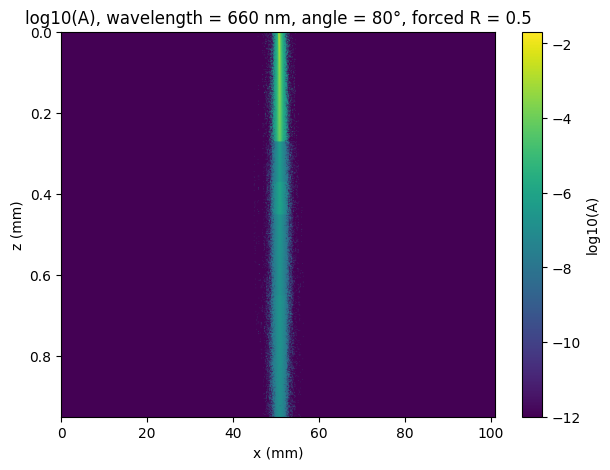

In [110]:
wl_test = 660
theta_test = 80
N_test = 50000

i_test = np.where(wavelength == wl_test)[0][0]

A_test = simulate_light_propagation(
    mu_a_refined,
    mu_s_refined,
    n_refined,
    theta0_deg=theta_test,
    N_photons=N_test,
    debug=False
)

plt.figure(figsize=(7,5))
plt.imshow(np.log10(A_test + 1e-12),
           extent=[0, mu_a_refined.shape[1] * x_step, mu_a_refined.shape[0] * z_step, 0],
           aspect='auto',
           cmap='viridis')
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title(f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°, forced R = 0.5")
plt.colorbar(label="log10(A)")
plt.show()

# GARBAGE 


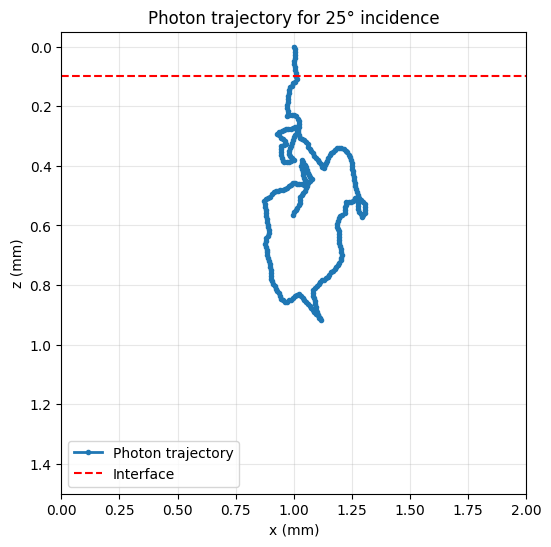

Initial angle = 25 deg
Reflected angle = 172.923 deg
Refracted angle = 7.2305 deg


In [19]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 1. COMPUTE REFLECTION AND REFRACTION ANGLES
# =========================================================

def compute_reflection_and_refraction_angles(
    incident_angle_deg,
    refractive_index_1,
    refractive_index_2
):
    """
    Angles are measured from the normal to the interface.

    Returns:
    - reflected_angle_deg
    - refracted_angle_deg (or None if total internal reflection)
    - total_internal_reflection (True/False)
    """

    incident_angle_rad = np.deg2rad(incident_angle_deg)

    # Reflection law
    reflected_angle_deg = (180 - incident_angle_deg) 

    # Snell law
    snell_argument = (refractive_index_1 / refractive_index_2) * np.sin(incident_angle_rad)

    if abs(snell_argument) > 1.0:
        return reflected_angle_deg, None, True

    refracted_angle_rad = np.arcsin(snell_argument)
    refracted_angle_deg = np.rad2deg(refracted_angle_rad)

    return reflected_angle_deg, refracted_angle_deg, False


# =========================================================
# 2. HENYEY-GREENSTEIN SCATTERING ANGLE
# =========================================================

def sample_henyey_greenstein_scattering_angle(g_value, rng_object):
    """
    Sample one scattering angle from the HG phase function.
    """

    random_number = rng_object.uniform()

    if np.isclose(g_value, 0.0):
        cosine_theta = 2.0 * random_number - 1.0
    else:
        numerator_part_1 = 1.0 + g_value**2
        numerator_part_2 = 1.0 - g_value**2
        denominator_part = 1.0 - g_value + 2.0 * g_value * random_number

        fraction_term = numerator_part_2 / denominator_part
        fraction_term_squared = fraction_term**2

        cosine_theta = (1.0 / (2.0 * g_value)) * (numerator_part_1 - fraction_term_squared)

    if cosine_theta < -1.0:
        cosine_theta = -1.0
    if cosine_theta > 1.0:
        cosine_theta = 1.0

    scattering_angle_rad = np.arccos(cosine_theta)

    return scattering_angle_rad


# =========================================================
# 3. UPDATE DIRECTION AFTER OPTIONAL 2D SCATTERING
# =========================================================

def update_direction_after_2d_scattering(old_mu_x, old_mu_z, g_value, rng_object):
    """
    Update 2D direction in x-z plane after one random scattering event.
    """

    scattering_angle_rad = sample_henyey_greenstein_scattering_angle(g_value, rng_object)

    random_sign_number = rng_object.uniform()

    if random_sign_number < 0.5:
        angle_sign = -1.0
    else:
        angle_sign = 1.0

    old_angle_from_normal = np.arctan2(old_mu_x, old_mu_z)
    new_angle_from_normal = old_angle_from_normal + angle_sign * scattering_angle_rad

    new_mu_x = np.sin(new_angle_from_normal)
    new_mu_z = np.cos(new_angle_from_normal)

    direction_norm = np.sqrt(new_mu_x**2 + new_mu_z**2)

    new_mu_x = new_mu_x / direction_norm
    new_mu_z = new_mu_z / direction_norm

    return new_mu_x, new_mu_z


# =========================================================
# 4. TRACE ONE PHOTON PACKET TRAJECTORY
# =========================================================

def trace_one_photon_with_initial_angle(
    initial_angle_deg,
    starting_x_mm=1.0,
    starting_z_mm=0.0,
    interface_z_mm=0.1,
    refractive_index_above=1.42,
    refractive_index_below=1.39,
    step_length_mm=0.01,
    maximum_number_of_steps=300,
    use_scattering=False,
    anisotropy_g=0.9,
    x_min_mm=0.0,
    x_max_mm=2.0,
    z_min_mm=-0.2,
    z_max_mm=2.0,
    random_seed=12345
):
    """
    Trace one photon packet trajectory starting with a chosen initial angle.

    Parameters
    ----------
    initial_angle_deg : float
        Initial angle in degrees, measured from the normal.
    starting_x_mm : float
        Initial x position.
    starting_z_mm : float
        Initial z position.
    interface_z_mm : float
        z position of the refractive-index interface.
    refractive_index_above : float
        Refractive index above the interface.
    refractive_index_below : float
        Refractive index below the interface.
    step_length_mm : float
        Distance traveled per step for the visualization.
    maximum_number_of_steps : int
        Maximum number of propagation steps.
    use_scattering : bool
        If True, random scattering is added after each propagation step.
    anisotropy_g : float
        HG anisotropy factor for scattering.
    x_min_mm, x_max_mm, z_min_mm, z_max_mm : float
        Plot / simulation window limits.
    random_seed : int
        Random seed for reproducibility.
    """

    rng_object = np.random.default_rng(random_seed)

    # Initial direction from angle measured from the normal
    initial_angle_rad = np.deg2rad(initial_angle_deg)
    mu_x = np.sin(initial_angle_rad)
    mu_z = np.cos(initial_angle_rad)

    photon_x_mm = starting_x_mm
    photon_z_mm = starting_z_mm

    x_positions_mm = [photon_x_mm]
    z_positions_mm = [photon_z_mm]

    interface_hit = False
    reflected_angle_deg = None
    refracted_angle_deg = None
    total_internal_reflection = False

    medium_index = 1   # 1 = above, 2 = below

    for step_index in range(maximum_number_of_steps):

        old_x_mm = photon_x_mm
        old_z_mm = photon_z_mm

        new_x_mm = old_x_mm + mu_x * step_length_mm
        new_z_mm = old_z_mm + mu_z * step_length_mm

        # -------------------------------------------------
        # Check if interface is crossed during this step
        # -------------------------------------------------
        crossed_interface_now = ((old_z_mm - interface_z_mm) * (new_z_mm - interface_z_mm) < 0.0)

        if crossed_interface_now:
            # Find exact interface crossing position
            if new_z_mm != old_z_mm:
                interpolation_fraction = (interface_z_mm - old_z_mm) / (new_z_mm - old_z_mm)
            else:
                interpolation_fraction = 0.0

            x_cross_mm = old_x_mm + interpolation_fraction * (new_x_mm - old_x_mm)
            z_cross_mm = interface_z_mm

            x_positions_mm.append(x_cross_mm)
            z_positions_mm.append(z_cross_mm)

            # Angle of incidence from the normal
            incident_angle_rad_local = np.arctan2(abs(mu_x), abs(mu_z))
            incident_angle_deg_local = np.rad2deg(incident_angle_rad_local)

            # Decide which side we are coming from
            if medium_index == 1:
                n1 = refractive_index_above
                n2 = refractive_index_below
            else:
                n1 = refractive_index_below
                n2 = refractive_index_above

            reflected_angle_deg, refracted_angle_deg, total_internal_reflection = compute_reflection_and_refraction_angles(
                incident_angle_deg_local,
                n1,
                n2
            )

            interface_hit = True

            # -------------------------------------------------
            # If total internal reflection: reflect
            # -------------------------------------------------
            if total_internal_reflection:
                mu_z = -mu_z

                photon_x_mm = x_cross_mm
                photon_z_mm = z_cross_mm

                x_positions_mm.append(photon_x_mm)
                z_positions_mm.append(photon_z_mm)

                continue

            # -------------------------------------------------
            # Otherwise: refract through interface
            # -------------------------------------------------
            refracted_angle_rad = np.deg2rad(refracted_angle_deg)

            sign_x = np.sign(mu_x)
            if sign_x == 0:
                sign_x = 1.0

            # Determine whether photon continues downward or upward
            # based on which medium it enters
            if medium_index == 1:
                # going from above to below
                mu_x = sign_x * np.sin(refracted_angle_rad)
                mu_z = np.cos(refracted_angle_rad)
                medium_index = 2
            else:
                # going from below to above
                mu_x = sign_x * np.sin(refracted_angle_rad)
                mu_z = -np.cos(refracted_angle_rad)
                medium_index = 1

            photon_x_mm = x_cross_mm
            photon_z_mm = z_cross_mm

            x_positions_mm.append(photon_x_mm)
            z_positions_mm.append(photon_z_mm)

            continue

        # -------------------------------------------------
        # Normal propagation
        # -------------------------------------------------
        photon_x_mm = new_x_mm
        photon_z_mm = new_z_mm

        x_positions_mm.append(photon_x_mm)
        z_positions_mm.append(photon_z_mm)

        # -------------------------------------------------
        # Optional scattering
        # -------------------------------------------------
        if use_scattering:
            mu_x, mu_z = update_direction_after_2d_scattering(
                mu_x,
                mu_z,
                anisotropy_g,
                rng_object
            )

        # -------------------------------------------------
        # Stop if photon exits viewing window
        # -------------------------------------------------
        if photon_x_mm < x_min_mm or photon_x_mm > x_max_mm:
            break

        if photon_z_mm < z_min_mm or photon_z_mm > z_max_mm:
            break

    results = {
        "x_positions_mm": np.array(x_positions_mm),
        "z_positions_mm": np.array(z_positions_mm),
        "initial_angle_deg": initial_angle_deg,
        "interface_hit": interface_hit,
        "reflected_angle_deg": reflected_angle_deg,
        "refracted_angle_deg": refracted_angle_deg,
        "total_internal_reflection": total_internal_reflection
    }

    return results


# =========================================================
# 5. PLOT ONE PHOTON TRAJECTORY
# =========================================================

def plot_one_photon_trajectory(
    photon_results,
    interface_z_mm=0.1,
    x_min_mm=0.0,
    x_max_mm=2.0,
    z_min_mm=-0.05,
    z_max_mm=1.5,
    figure_title="Single photon packet trajectory"
):
    """
    Plot one photon packet trajectory in x-z.
    """

    x_positions_mm = photon_results["x_positions_mm"]
    z_positions_mm = photon_results["z_positions_mm"]

    initial_angle_deg = photon_results["initial_angle_deg"]
    interface_hit = photon_results["interface_hit"]
    reflected_angle_deg = photon_results["reflected_angle_deg"]
    refracted_angle_deg = photon_results["refracted_angle_deg"]
    total_internal_reflection = photon_results["total_internal_reflection"]

    plt.figure(figsize=(6, 6))

    plt.plot(
        x_positions_mm,
        z_positions_mm,
        linewidth=2,
        marker="o",
        markersize=3,
        label="Photon trajectory"
    )

    plt.axhline(interface_z_mm, color="red", linestyle="--", label="Interface")

    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(figure_title)

    plt.xlim(x_min_mm, x_max_mm)
    plt.ylim(z_max_mm, z_min_mm)   # inverted so depth increases downward
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("Initial angle =", initial_angle_deg, "deg")

    if interface_hit:
        if reflected_angle_deg is not None:
            print("Reflected angle =", round(reflected_angle_deg, 4), "deg")

        if total_internal_reflection:
            print("Refracted angle = none (total internal reflection)")
        elif refracted_angle_deg is not None:
            print("Refracted angle =", round(refracted_angle_deg, 4), "deg")
    else:
        print("The photon did not hit the interface in the plotted window.")


# =========================================================
# 6. OPTIONAL: RUN MULTIPLE ANGLES
# =========================================================

def run_multiple_incidence_angles(
    angle_list_deg,
    starting_x_mm=1.0,
    starting_z_mm=0.0,
    interface_z_mm=0.1,
    refractive_index_above=1.42,
    refractive_index_below=1.39,
    step_length_mm=0.01,
    maximum_number_of_steps=300,
    use_scattering=False,
    anisotropy_g=0.9
):
    """
    Run and plot one trajectory for each angle in angle_list_deg.
    """

    for one_angle_deg in angle_list_deg:
        photon_results = trace_one_photon_with_initial_angle(
            initial_angle_deg=one_angle_deg,
            starting_x_mm=starting_x_mm,
            starting_z_mm=starting_z_mm,
            interface_z_mm=interface_z_mm,
            refractive_index_above=refractive_index_above,
            refractive_index_below=refractive_index_below,
            step_length_mm=step_length_mm,
            maximum_number_of_steps=maximum_number_of_steps,
            use_scattering=use_scattering,
            anisotropy_g=anisotropy_g,
            random_seed=12345
        )

        plot_one_photon_trajectory(
            photon_results,
            interface_z_mm=interface_z_mm,
            figure_title="Photon trajectory for initial angle = " + str(one_angle_deg) + "°"
        )


# =========================================================
# 7. MAIN EXAMPLES
# =========================================================

if __name__ == "__main__":

    # ---------------------------------------------
    # Example A: one clean geometric trajectory
    # ---------------------------------------------
    photon_results = trace_one_photon_with_initial_angle(
        initial_angle_deg=25,
        starting_x_mm=1.0,
        starting_z_mm=0.0,
        interface_z_mm=0.1,
        refractive_index_above=1.42,
        refractive_index_below=1.39,
        step_length_mm=0.01,
        maximum_number_of_steps=300,
        use_scattering=False
    )

    plot_one_photon_trajectory(
        photon_results,
        interface_z_mm=0.1,
        figure_title="Photon trajectory for 25° incidence"
    )

    # ---------------------------------------------
    # Example B: several angles
    # Uncomment if you want multiple plots
    # ---------------------------------------------
    # angle_list_deg = [0, 10, 20, 30, 40, 50, 60, 70]
    # run_multiple_incidence_angles(
    #     angle_list_deg,
    #     starting_x_mm=1.0,
    #     starting_z_mm=0.0,
    #     interface_z_mm=0.1,
    #     refractive_index_above=1.42,
    #     refractive_index_below=1.39,
    #     step_length_mm=0.01,
    #     maximum_number_of_steps=300,
    #     use_scattering=False
    # )

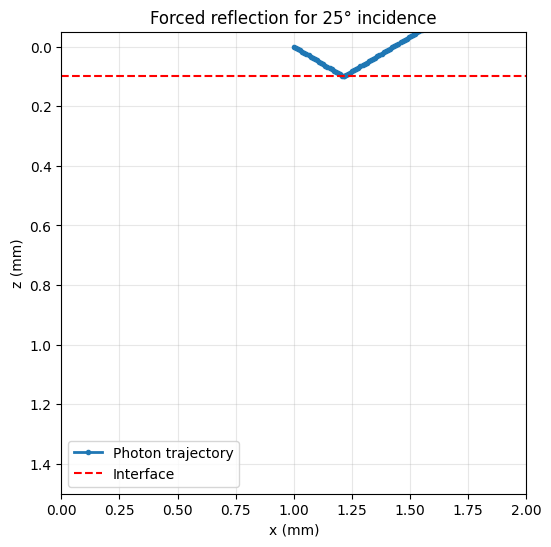

Initial launch angle from normal = 65 deg
Interface mode = reflect
Incident angle from normal = 65.0 deg
Reflected angle from normal = 65.0 deg
Refracted angle from normal = 67.7997 deg
Incoming heading from +z axis = 65.0 deg
Outgoing heading from +z axis = 115.0 deg


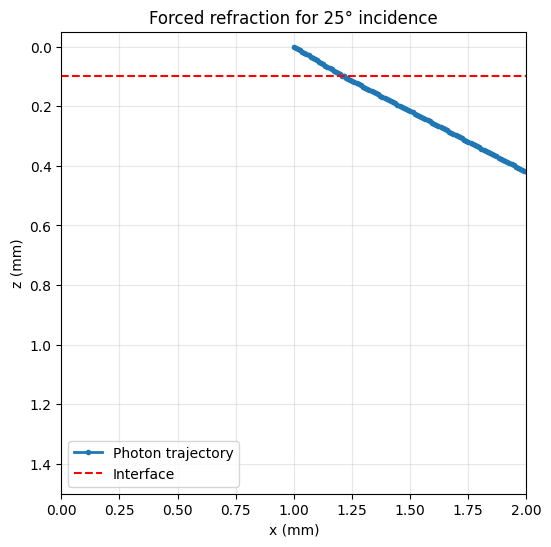

Initial launch angle from normal = 65 deg
Interface mode = refract
Incident angle from normal = 65.0 deg
Reflected angle from normal = 65.0 deg
Refracted angle from normal = 67.7997 deg
Incoming heading from +z axis = 65.0 deg
Outgoing heading from +z axis = 67.7997 deg


In [34]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 1. ANGLE HELPER FUNCTIONS
# =========================================================

def compute_reflection_and_refraction_angles_from_normal(
    incident_angle_deg,
    refractive_index_1,
    refractive_index_2
):
    """
    Angles are measured from the normal to the interface.

    Returns:
    - reflected_angle_deg_from_normal
    - refracted_angle_deg_from_normal (None if total internal reflection)
    - total_internal_reflection
    """

    incident_angle_rad = np.deg2rad(incident_angle_deg)

    reflected_angle_deg_from_normal = incident_angle_deg

    snell_argument = (refractive_index_1 / refractive_index_2) * np.sin(incident_angle_rad)

    if abs(snell_argument) > 1.0:
        return reflected_angle_deg_from_normal, None, True

    refracted_angle_rad = np.arcsin(snell_argument)
    refracted_angle_deg_from_normal = np.rad2deg(refracted_angle_rad)

    return reflected_angle_deg_from_normal, refracted_angle_deg_from_normal, False


def convert_direction_vector_to_heading_from_positive_z(mu_x, mu_z):
    """
    Returns the full heading angle in degrees in the x-z plane,
    measured from the +z direction.

    This is useful for visual interpretation of the trajectory direction.
    """

    heading_angle_rad = np.arctan2(mu_x, mu_z)
    heading_angle_deg = np.rad2deg(heading_angle_rad)

    if heading_angle_deg < 0:
        heading_angle_deg = heading_angle_deg + 360.0

    return heading_angle_deg


# =========================================================
# 2. OPTIONAL SCATTERING
# =========================================================

def sample_henyey_greenstein_scattering_angle(g_value, rng_object):
    random_number = rng_object.uniform()

    if np.isclose(g_value, 0.0):
        cosine_theta = 2.0 * random_number - 1.0
    else:
        numerator_part_1 = 1.0 + g_value**2
        numerator_part_2 = 1.0 - g_value**2
        denominator_part = 1.0 - g_value + 2.0 * g_value * random_number

        fraction_term = numerator_part_2 / denominator_part
        fraction_term_squared = fraction_term**2

        cosine_theta = (1.0 / (2.0 * g_value)) * (numerator_part_1 - fraction_term_squared)

    if cosine_theta < -1.0:
        cosine_theta = -1.0
    if cosine_theta > 1.0:
        cosine_theta = 1.0

    scattering_angle_rad = np.arccos(cosine_theta)
    return scattering_angle_rad


def update_direction_after_2d_scattering(old_mu_x, old_mu_z, g_value, rng_object):
    scattering_angle_rad = sample_henyey_greenstein_scattering_angle(g_value, rng_object)

    random_sign_number = rng_object.uniform()

    if random_sign_number < 0.5:
        angle_sign = -1.0
    else:
        angle_sign = 1.0

    old_angle_from_normal = np.arctan2(old_mu_x, old_mu_z)
    new_angle_from_normal = old_angle_from_normal + angle_sign * scattering_angle_rad

    new_mu_x = np.sin(new_angle_from_normal)
    new_mu_z = np.cos(new_angle_from_normal)

    direction_norm = np.sqrt(new_mu_x**2 + new_mu_z**2)

    new_mu_x = new_mu_x / direction_norm
    new_mu_z = new_mu_z / direction_norm

    return new_mu_x, new_mu_z


# =========================================================
# 3. TRACE ONE PHOTON PACKET
# =========================================================

def trace_one_photon_with_initial_angle(
    initial_angle_deg,
    starting_x_mm=1.0,
    starting_z_mm=0.0,
    interface_z_mm=0.1,
    refractive_index_above=1.42,
    refractive_index_below=1.39,
    step_length_mm=0.01,
    maximum_number_of_steps=300,
    interface_mode="refract",   # "reflect", "refract", or "auto"
    use_scattering=False,
    anisotropy_g=0.9,
    x_min_mm=0.0,
    x_max_mm=2.0,
    z_min_mm=-0.2,
    z_max_mm=2.0,
    random_seed=12345
):
    """
    Trace one photon packet trajectory with a chosen initial angle.

    initial_angle_deg is measured from the normal, toward +x.
    So:
        mu_x = sin(theta)
        mu_z = cos(theta)

    interface_mode:
        "reflect" -> force reflection at the interface
        "refract" -> force transmission/refraction at the interface
        "auto"    -> refract unless total internal reflection occurs
    """

    rng_object = np.random.default_rng(random_seed)

    initial_angle_rad = np.deg2rad(initial_angle_deg)

    mu_x = np.sin(initial_angle_rad)
    mu_z = np.cos(initial_angle_rad)

    photon_x_mm = starting_x_mm
    photon_z_mm = starting_z_mm

    x_positions_mm = [photon_x_mm]
    z_positions_mm = [photon_z_mm]

    interface_hit = False
    total_internal_reflection = False

    incident_angle_deg_from_normal = None
    reflected_angle_deg_from_normal = None
    refracted_angle_deg_from_normal = None

    incoming_heading_deg = None
    outgoing_heading_deg = None

    current_medium = "above"

    for step_index in range(maximum_number_of_steps):

        old_x_mm = photon_x_mm
        old_z_mm = photon_z_mm

        new_x_mm = old_x_mm + mu_x * step_length_mm
        new_z_mm = old_z_mm + mu_z * step_length_mm

        crossed_interface_now = ((old_z_mm - interface_z_mm) * (new_z_mm - interface_z_mm) < 0.0)

        if crossed_interface_now and not interface_hit:

            interface_hit = True

            if new_z_mm != old_z_mm:
                interpolation_fraction = (interface_z_mm - old_z_mm) / (new_z_mm - old_z_mm)
            else:
                interpolation_fraction = 0.0

            x_cross_mm = old_x_mm + interpolation_fraction * (new_x_mm - old_x_mm)
            z_cross_mm = interface_z_mm

            # Save exact crossing point
            x_positions_mm.append(x_cross_mm)
            z_positions_mm.append(z_cross_mm)

            incident_angle_rad_local = np.arctan2(abs(mu_x), abs(mu_z))
            incident_angle_deg_from_normal = np.rad2deg(incident_angle_rad_local)

            incoming_heading_deg = convert_direction_vector_to_heading_from_positive_z(mu_x, mu_z)

            if current_medium == "above":
                n1 = refractive_index_above
                n2 = refractive_index_below
            else:
                n1 = refractive_index_below
                n2 = refractive_index_above

            reflected_angle_deg_from_normal, refracted_angle_deg_from_normal, total_internal_reflection = compute_reflection_and_refraction_angles_from_normal(
                incident_angle_deg_from_normal,
                n1,
                n2
            )

            # -------------------------------------------------
            # Case 1: force reflection
            # -------------------------------------------------
            if interface_mode == "reflect":
                mu_z = -mu_z
                outgoing_heading_deg = convert_direction_vector_to_heading_from_positive_z(mu_x, mu_z)

            # -------------------------------------------------
            # Case 2: automatic behavior
            # -------------------------------------------------
            elif interface_mode == "auto":
                if total_internal_reflection:
                    mu_z = -mu_z
                    outgoing_heading_deg = convert_direction_vector_to_heading_from_positive_z(mu_x, mu_z)
                else:
                    refracted_angle_rad = np.deg2rad(refracted_angle_deg_from_normal)

                    sign_x = np.sign(mu_x)
                    if sign_x == 0:
                        sign_x = 1.0

                    if current_medium == "above":
                        mu_x = sign_x * np.sin(refracted_angle_rad)
                        mu_z = np.cos(refracted_angle_rad)
                        current_medium = "below"
                    else:
                        mu_x = sign_x * np.sin(refracted_angle_rad)
                        mu_z = -np.cos(refracted_angle_rad)
                        current_medium = "above"

                    outgoing_heading_deg = convert_direction_vector_to_heading_from_positive_z(mu_x, mu_z)

            # -------------------------------------------------
            # Case 3: force refraction
            # -------------------------------------------------
            elif interface_mode == "refract":
                if total_internal_reflection:
                    # If impossible to refract physically, reflect
                    mu_z = -mu_z
                    outgoing_heading_deg = convert_direction_vector_to_heading_from_positive_z(mu_x, mu_z)
                else:
                    refracted_angle_rad = np.deg2rad(refracted_angle_deg_from_normal)

                    sign_x = np.sign(mu_x)
                    if sign_x == 0:
                        sign_x = 1.0

                    if current_medium == "above":
                        mu_x = sign_x * np.sin(refracted_angle_rad)
                        mu_z = np.cos(refracted_angle_rad)
                        current_medium = "below"
                    else:
                        mu_x = sign_x * np.sin(refracted_angle_rad)
                        mu_z = -np.cos(refracted_angle_rad)
                        current_medium = "above"

                    outgoing_heading_deg = convert_direction_vector_to_heading_from_positive_z(mu_x, mu_z)

            else:
                raise ValueError("interface_mode must be 'reflect', 'refract', or 'auto'")

            # Restart exactly from interface with new direction
            photon_x_mm = x_cross_mm
            photon_z_mm = z_cross_mm

            x_positions_mm.append(photon_x_mm)
            z_positions_mm.append(photon_z_mm)

            continue

        photon_x_mm = new_x_mm
        photon_z_mm = new_z_mm

        x_positions_mm.append(photon_x_mm)
        z_positions_mm.append(photon_z_mm)

        if use_scattering:
            mu_x, mu_z = update_direction_after_2d_scattering(
                mu_x,
                mu_z,
                anisotropy_g,
                rng_object
            )

        if photon_x_mm < x_min_mm or photon_x_mm > x_max_mm:
            break

        if photon_z_mm < z_min_mm or photon_z_mm > z_max_mm:
            break

    results = {
        "x_positions_mm": np.array(x_positions_mm),
        "z_positions_mm": np.array(z_positions_mm),
        "initial_angle_deg": initial_angle_deg,
        "interface_hit": interface_hit,
        "incident_angle_deg_from_normal": incident_angle_deg_from_normal,
        "reflected_angle_deg_from_normal": reflected_angle_deg_from_normal,
        "refracted_angle_deg_from_normal": refracted_angle_deg_from_normal,
        "incoming_heading_deg": incoming_heading_deg,
        "outgoing_heading_deg": outgoing_heading_deg,
        "total_internal_reflection": total_internal_reflection,
        "interface_mode": interface_mode
    }

    return results


# =========================================================
# 4. PLOT TRAJECTORY
# =========================================================

def plot_one_photon_trajectory(
    photon_results,
    interface_z_mm=0.1,
    x_min_mm=0.0,
    x_max_mm=2.0,
    z_min_mm=-0.05,
    z_max_mm=1.5,
    figure_title="Single photon packet trajectory"
):
    x_positions_mm = photon_results["x_positions_mm"]
    z_positions_mm = photon_results["z_positions_mm"]

    plt.figure(figsize=(6, 6))

    plt.plot(
        x_positions_mm,
        z_positions_mm,
        linewidth=2,
        marker="o",
        markersize=3,
        label="Photon trajectory"
    )

    plt.axhline(interface_z_mm, color="red", linestyle="--", label="Interface")

    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(figure_title)

    plt.xlim(x_min_mm, x_max_mm)
    plt.ylim(z_max_mm, z_min_mm)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("Initial launch angle from normal =", photon_results["initial_angle_deg"], "deg")
    print("Interface mode =", photon_results["interface_mode"])

    if photon_results["interface_hit"]:
        print("Incident angle from normal =", round(photon_results["incident_angle_deg_from_normal"], 4), "deg")

        if photon_results["reflected_angle_deg_from_normal"] is not None:
            print("Reflected angle from normal =", round(photon_results["reflected_angle_deg_from_normal"], 4), "deg")

        if photon_results["total_internal_reflection"]:
            print("Refracted angle from normal = none (total internal reflection)")
        elif photon_results["refracted_angle_deg_from_normal"] is not None:
            print("Refracted angle from normal =", round(photon_results["refracted_angle_deg_from_normal"], 4), "deg")

        if photon_results["incoming_heading_deg"] is not None:
            print("Incoming heading from +z axis =", round(photon_results["incoming_heading_deg"], 4), "deg")

        if photon_results["outgoing_heading_deg"] is not None:
            print("Outgoing heading from +z axis =", round(photon_results["outgoing_heading_deg"], 4), "deg")
    else:
        print("The photon did not hit the interface in the plotted window.")


# =========================================================
# 5. EXAMPLES
# =========================================================

if __name__ == "__main__":

    # Example A: forced reflection
    reflected_photon = trace_one_photon_with_initial_angle(
        initial_angle_deg=65,
        starting_x_mm=1.0,
        starting_z_mm=0.0,
        interface_z_mm=0.1,
        refractive_index_above=1.42,
        refractive_index_below=1.39,
        step_length_mm=0.01,
        maximum_number_of_steps=300,
        interface_mode="reflect",
        use_scattering=False
    )

    plot_one_photon_trajectory(
        reflected_photon,
        interface_z_mm=0.1,
        figure_title="Forced reflection for 25° incidence"
    )

    # Example B: forced refraction
    refracted_photon = trace_one_photon_with_initial_angle(
        initial_angle_deg=65,
        starting_x_mm=1.0,
        starting_z_mm=0.0,
        interface_z_mm=0.1,
        refractive_index_above=1.42,
        refractive_index_below=1.39,
        step_length_mm=0.01,
        maximum_number_of_steps=300,
        interface_mode="refract",
        use_scattering=False
    )

    plot_one_photon_trajectory(
        refracted_photon,
        interface_z_mm=0.1,
        figure_title="Forced refraction for 25° incidence"
    )